In [5]:
import zipfile
import os
import shutil
import random

# ──  Extract ──────────────────────────────────────────
with zipfile.ZipFile(r'archive7.zip', 'r') as z:
    z.extractall('dataset1')

with zipfile.ZipFile(r'archive8.zip', 'r') as z:
    z.extractall('dataset2')

# ──  Collect all classes + images ─────────────────────
all_classes = {} 

flowers_root = 'dataset1/flowers'
for cls in os.listdir(flowers_root):
    cls_path = os.path.join(flowers_root, cls)
    if os.path.isdir(cls_path):
        images = [os.path.join(cls_path, f) for f in os.listdir(cls_path)]
        all_classes[cls.lower()] = images


In [6]:
train_root = 'dataset2/split_ttv_dataset_type_of_plants/Train_Set_Folder'
for cls in os.listdir(train_root):
    cls_path = os.path.join(train_root, cls)
    if os.path.isdir(cls_path):
        images = [os.path.join(cls_path, f) for f in os.listdir(cls_path)]
        all_classes[cls.lower()] = images

# ──  Find minimum class size 
class_sizes = {cls: len(imgs) for cls, imgs in all_classes.items()}
print("Class sizes:")
for cls, size in sorted(class_sizes.items()):
    print(f"  {cls}: {size}")

min_size = min(class_sizes.values())
print(f"\nMinimum class size: {min_size} → will undersample to this")

# ──  Build combined dataset
output_dir = 'plants_combined'
os.makedirs(output_dir, exist_ok=True)

for cls, images in all_classes.items():
    out_cls_dir = os.path.join(output_dir, cls)
    os.makedirs(out_cls_dir, exist_ok=True)
    
    selected = random.sample(images, min_size)
    for img_path in selected:
        shutil.copy(img_path, out_cls_dir)

print(f"\nDone! Combined dataset saved to '{output_dir}'")
print(f"   {len(all_classes)} classes × {min_size} images = {len(all_classes) * min_size} total images")

Class sizes:
  aloevera: 799
  banana: 799
  bilimbi: 799
  cantaloupe: 799
  cassava: 799
  coconut: 799
  corn: 799
  cucumber: 800
  curcuma: 799
  daisy: 764
  dandelion: 1052
  eggplant: 799
  galangal: 799
  gerbera: 600
  ginger: 799
  guava: 799
  hydrangea: 667
  kale: 799
  lily: 600
  longbeans: 799
  lotusflower: 604
  mango: 799
  melon: 799
  orange: 799
  paddy: 799
  papaya: 799
  peper chili: 799
  pineapple: 799
  pomelo: 799
  rose: 784
  shallot: 799
  soybeans: 800
  spinach: 799
  sunflower: 733
  sweet potatoes: 799
  tobacco: 799
  tulip: 984
  waterapple: 799
  watermelon: 799

Minimum class size: 600 → will undersample to this

Done! Combined dataset saved to 'plants_combined'
   39 classes × 600 images = 23400 total images


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
DATA_DIR = 'plants_combined'
NUM_CLASSES = 39

In [15]:
datagen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
    # NO rescale here!
)

train_gen = datagen.flow_from_directory(DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE),
                                        batch_size=BATCH_SIZE, class_mode='categorical', subset='training')

val_gen = datagen.flow_from_directory(DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE),
                                      batch_size=BATCH_SIZE, class_mode='categorical', subset='validation')

Found 18720 images belonging to 39 classes.
Found 4680 images belonging to 39 classes.


In [16]:
base_model = EfficientNetV2S(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(" Model ready!")

 Model ready!


In [17]:
history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS,
                    callbacks=[
                        tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
                        tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
                    ])

Epoch 1/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 617s 1s/step - accuracy: 0.7154 - loss: 1.1537 - val_accuracy: 0.8370 - val_loss: 0.5945 - learning_rate: 0.0010
Epoch 2/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 518s 885ms/step - accuracy: 0.8409 - loss: 0.5646 - val_accuracy: 0.8690 - val_loss: 0.4523 - learning_rate: 0.0010
Epoch 3/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 503s 860ms/step - accuracy: 0.8635 - loss: 0.4608 - val_accuracy: 0.8887 - val_loss: 0.3872 - learning_rate: 0.0010
Epoch 4/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 495s 846ms/step - accuracy: 0.8794 - loss: 0.4020 - val_accuracy: 0.9009 - val_loss: 0.3469 - learning_rate: 0.0010
Epoch 5/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 493s 842ms/step - accuracy: 0.8877 - loss: 0.3707 - val_accuracy: 0.9081 - val_loss: 0.3263 - learning_rate: 0.0010
Epoch 6/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 493s 842ms/step - accuracy: 0.8957 - loss: 0.3415 - val_accuracy: 0.9085 - val_loss: 0.2990 - learning_rate: 0.0010
Epoch 7/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 492s 841ms/step - accuracy:

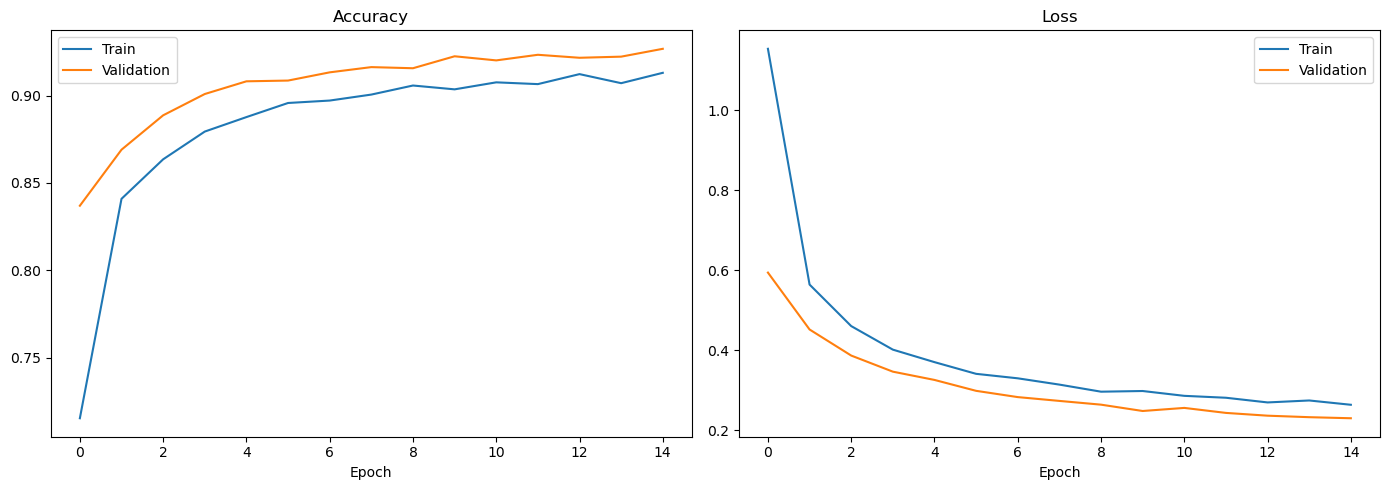

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_graphs.png')
plt.show()

In [24]:
from sklearn.metrics import confusion_matrix
import numpy as np

X_sample, y_true_batch = next(val_gen)
y_pred = np.argmax(model.predict(X_sample), axis=1)
y_true = np.argmax(y_true_batch, axis=1)

# Use only classes present in this batch
present_classes = np.unique(np.concatenate([y_true, y_pred]))
cm = confusion_matrix(y_true, y_pred, labels=present_classes)

TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (TP + FP + FN)

class_names = list(train_gen.class_indices.keys())

print(f"{'Class':<20} {'TP':>5} {'FP':>5} {'TN':>5} {'FN':>5}")
print("-" * 40)
for idx, i in enumerate(present_classes):
    print(f"{class_names[i]:<20} {TP[idx]:>5} {FP[idx]:>5} {TN[idx]:>5} {FN[idx]:>5}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step
Class                   TP    FP    TN    FN
----------------------------------------
aloevera                 1     0    31     0
banana                   1     0    31     0
cassava                  1     0    31     0
coconut                  1     0    31     0
corn                     1     0    31     0
cucumber                 2     0    30     0
curcuma                  1     0    31     0
dandelion                1     0    31     0
eggplant                 3     0    29     0
gerbera                  1     0    31     0
ginger                   1     0    31     0
kale                     0     0    31     1
lily                     0     0    31     1
lotusflower              1     0    31     0
mango                    1     0    30     1
melon                    2     1    29     0
paddy                    1     0    31     0
papaya                   1     0    31     0
peper chili              1     0    31     0
pineapple           

C:\Users\amina\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\amina\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


In [38]:
print(f"Train Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Train Loss:     {history.history['loss'][-1]:.4f}")
print(f"Val Accuracy:   {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"Val Loss:       {history.history['val_loss'][-1]:.4f}")

Train Accuracy: 91.30%
Train Loss:     0.2642
Val Accuracy:   92.67%
Val Loss:       0.2305


In [25]:
model.save('plant_model.h5')

class_labels = {v: k for k, v in train_gen.class_indices.items()}
with open('plant_labels.json', 'w') as f:
    json.dump(class_labels, f)

print(" plant_model.h5 saved")
print(" plant_labels.json saved")

 plant_model.h5 saved
 plant_labels.json saved


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


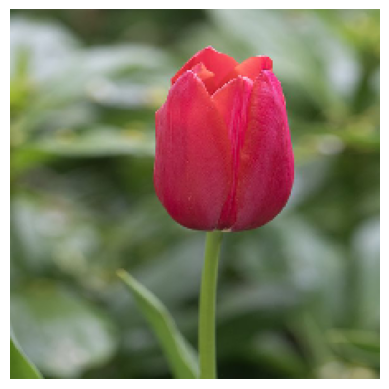

Tulip 99% | Rose 1% | Daisy 0%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


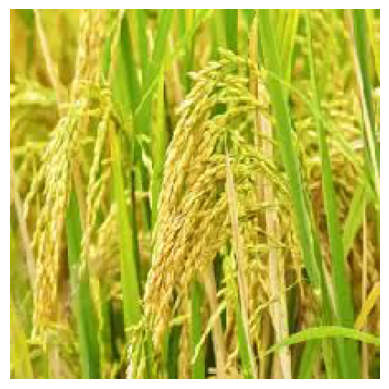

Paddy 100% | Kale 0% | Soybeans 0%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


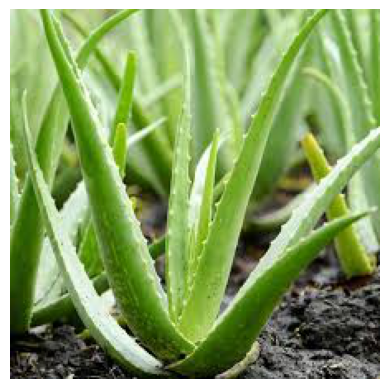

Aloevera 100% | Longbeans 0% | Lotusflower 0%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


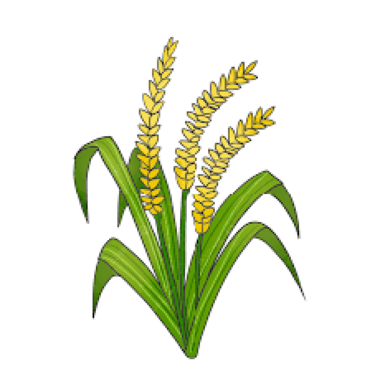

Pineapple 40% | Paddy 15% | Lily 11%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


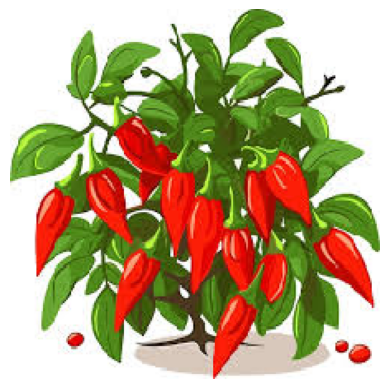

Lily 72% | Tulip 10% | Peper chili 6%


In [36]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_plant(img_path, top=3):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]
    top_indices = preds.argsort()[-top:][::-1]
    class_names = list(train_gen.class_indices.keys())

    plt.imshow(img)
    plt.axis('off')
    plt.show()

    results = [f"{class_names[i].capitalize()} {preds[i]*100:.0f}%" for i in top_indices]
    print(" | ".join(results))


predict_plant('daf83f8ccc1747e25c7415833cd0d234.jpg')
predict_plant('download1.jpg')
predict_plant('download.jpg')
predict_plant('images.png')
predict_plant("download3.jpg")


In [1]:
#################################FewShot#####################

In [2]:
import tensorflow as tf
import numpy as np
import json
import os
import ctypes
from tensorflow.keras.preprocessing import image as keras_image
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('plant_model.h5')

with open('plant_labels.json', 'r') as f:
    class_labels = json.load(f)

original_classes = list(class_labels.values())
IMG_SIZE = 224
BATCH_SIZE = 4
FEWSHOT_DIR = r'C:\Users\amina\Desktop\fewshots_plants'

print(" Ready!")

 Ready!


In [8]:
import random
fewshot_classes = os.listdir(FEWSHOT_DIR)
X, y = [], []
for cls in fewshot_classes:
    cls_path = os.path.join(FEWSHOT_DIR, cls)
    if cls not in original_classes: continue
    class_idx = original_classes.index(cls)
    for img_file in os.listdir(cls_path):
        if not img_file.endswith(('.jpg','.jpeg','.png')): continue
        try:
            img = keras_image.load_img(os.path.join(cls_path, img_file), target_size=(IMG_SIZE, IMG_SIZE))
            X.append(keras_image.img_to_array(img))
            label = np.zeros(39); label[class_idx] = 1
            y.append(label)
        except: pass
    main_cls = os.path.join('plants_combined', cls)
    if os.path.exists(main_cls):
        for img_file in random.sample(os.listdir(main_cls), 10):
            try:
                img = keras_image.load_img(os.path.join(main_cls, img_file), target_size=(IMG_SIZE, IMG_SIZE))
                X.append(keras_image.img_to_array(img))
                label = np.zeros(39); label[class_idx] = 1
                y.append(label)
            except: pass
X, y = np.array(X), np.array(y)
print(f" {len(X)} images loaded!")

 197 images loaded!


In [14]:
for layer in model.layers: layer.trainable = False
model.layers[-1].trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
print("Compiled!")

Compiled!


In [15]:
ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)
history = model.fit(X, y, epochs=50, batch_size=BATCH_SIZE,
                    callbacks=[tf.keras.callbacks.EarlyStopping(patience=8, monitor='loss', restore_best_weights=True)])
ctypes.windll.kernel32.SetThreadExecutionState(0x80000000)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 184ms/step - accuracy: 0.4569 - loss: 2.8040
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step - accuracy: 0.5228 - loss: 2.5966
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - accuracy: 0.5431 - loss: 2.3650
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.5228 - loss: 2.4074
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - accuracy: 0.5381 - loss: 2.0894
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - accuracy: 0.5939 - loss: 2.1149
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step - accuracy: 0.5939 - loss: 1.8337
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.6244 - loss: 1.9029
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - accuracy: 0.5838 - loss: 1.9057
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.6345 - loss: 1.6982
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.6548 - loss: 1.5261
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/ste

-2147483646

In [17]:
model.save('plant_model_fewshot.keras')

best_acc = max(history.history['accuracy'])
best_epoch = history.history['accuracy'].index(best_acc) + 1
best_loss = history.history['loss'][best_epoch - 1]

print(f" Saved!")
print(f"Best Accuracy: {best_acc*100:.2f}% (Epoch {best_epoch})")
print(f"Best Loss:     {best_loss:.4f}")

 Saved!
Best Accuracy: 88.83% (Epoch 42)
Best Loss:     0.4235


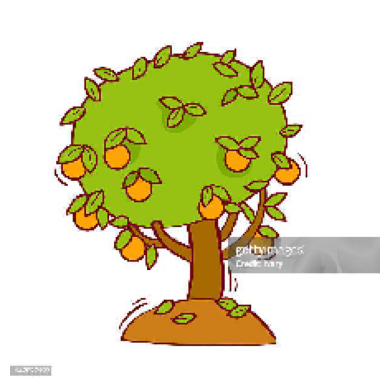

Orange 58% | Rose 9% | Gerbera 6%


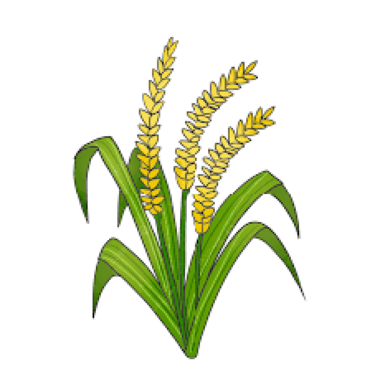

Paddy 72% | Corn 28% | Peper chili 1%


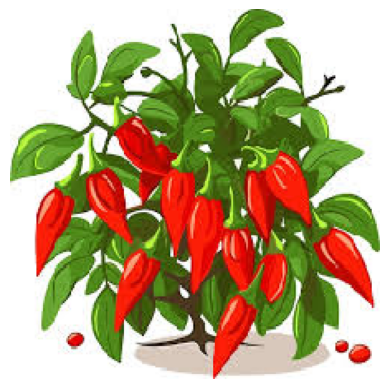

Peper chili 98% | Tulip 1% | Rose 0%


In [1]:
import tensorflow as tf
import numpy as np
import json
from tensorflow.keras.preprocessing import image as keras_image
import matplotlib.pyplot as plt

with open('plant_labels.json', 'r') as f:
    class_labels = json.load(f)
original_classes = list(class_labels.values())
IMG_SIZE = 224

model = tf.keras.models.load_model('plant_model_fewshot.keras')

def predict_plant_after_fewshot(img_path, top=3):
    img = keras_image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = np.expand_dims(keras_image.img_to_array(img), axis=0)
    preds = model.predict(img_array, verbose=0)[0]
    top_indices = preds.argsort()[-top:][::-1]
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    results = [f"{original_classes[i].capitalize()} {preds[i]*100:.0f}%" for i in top_indices]
    print(" | ".join(results))

predict_plant_after_fewshot('orange.jpg')
predict_plant_after_fewshot('images.png')
predict_plant_after_fewshot("download3.jpg")
